In [1]:
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

 cupy not imported 
2.2.1


In [3]:
scale=3
freqS=2.1*scale
freqL=3.4*scale
F.mse_loss

<function torch.nn.functional.mse_loss(input: torch.Tensor, target: torch.Tensor, size_average: Optional[bool] = None, reduce: Optional[bool] = None, reduction: str = 'mean') -> torch.Tensor>

In [4]:
N = 80
mult = 2*20
span = 2
x = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
y = np.sin(freqS*1*np.pi*x[:,0])*np.sin(freqL*1*np.pi*x[:,1])
xt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
yt = np.sin(freqS*1*np.pi*xt[:,0])*np.sin(freqL*1*np.pi*xt[:,1])
xtt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
ytt = np.sin(freqS*1*np.pi*xtt[:,0])*np.sin(freqL*1*np.pi*xtt[:,1])
xttt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
yttt = np.sin(freqS*1*np.pi*xttt[:,0])*np.sin(freqL*1*np.pi*xttt[:,1])
xtttt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
ytttt = np.sin(freqS*1*np.pi*xtttt[:,0])*np.sin(freqL*1*np.pi*xtttt[:,1])
xttttt = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
yttttt = np.sin(freqS*1*np.pi*xttttt[:,0])*np.sin(freqL*1*np.pi*xttttt[:,1])
xv = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
yv = np.sin(freqS*1*np.pi*xv[:,0])*np.sin(freqL*1*np.pi*xv[:,1])

scale = 3

y = np.sin(2.1*scale*np.pi*x[:,0])*np.sin(3.4*scale*np.pi*x[:,1])

In [5]:
print(x.shape)
print(x[:10,:])

(1600, 2)
[[ 0.19968604  0.82651593]
 [-0.33954362  0.38735372]
 [ 0.74119974 -0.49209573]
 [-0.87175156  0.95264821]
 [-0.88796938  0.11642916]
 [-0.75069822  0.52938463]
 [ 0.45460376  0.55569691]
 [-0.01487841 -0.91746163]
 [ 0.44249502 -0.4568323 ]
 [ 0.58120431  0.59882246]]


In [6]:
f = (np.random.rand(320000).reshape(-1,2)*2-1)*span/2.0 * 12

In [7]:
print(f.shape)
print(f[:10,:])
V=span*span

(160000, 2)
[[  7.62121644 -10.95688115]
 [ -0.97108373   8.14714239]
 [ -5.81854085  10.62930278]
 [ -3.77157083  -7.4811227 ]
 [ -9.28712108 -11.8328926 ]
 [  4.43668584   0.33907358]
 [ -5.34850869   7.54000207]
 [ 10.54823968  -9.80310881]
 [  6.20143132   4.53343045]
 [ -2.9518243  -10.49264459]]


(160000, 1)


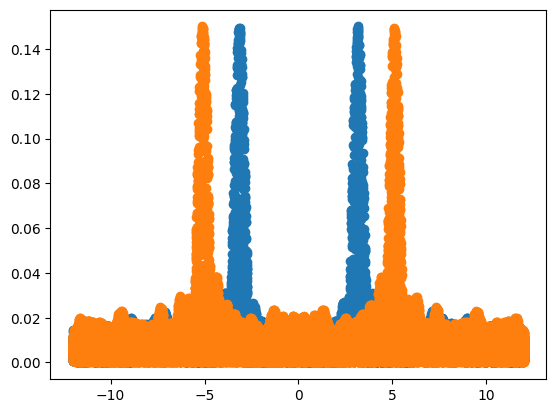

In [8]:
yf = (V/x.shape[0])*dft.nu_dft(x,y,f)/(np.sqrt(2*np.pi)**2)
print(yf.shape)
plt.scatter(f[:,0],np.abs(yf))
plt.scatter(f[:,1],np.abs(yf))

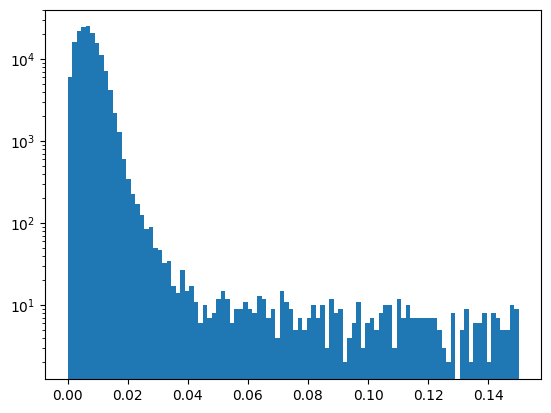

In [9]:
plt.hist(np.abs(yf),bins=100)
plt.yscale('log')

(160000, 1)
(160000, 2)
(160000, 1)


Text(0, 0.5, 'k')

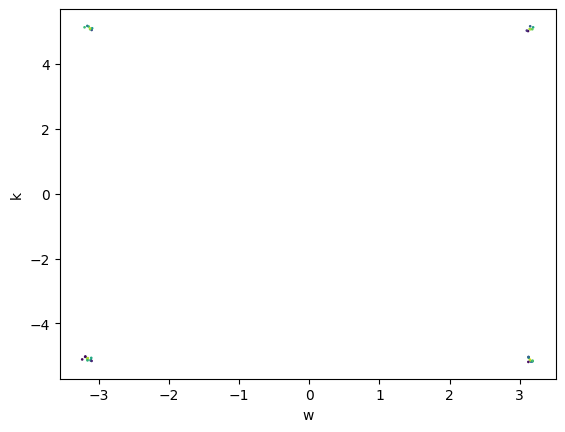

In [10]:
mask = dft.threshold_cmask(yf,np.max(np.abs(yf))*0.95)
print(mask.shape)
print(f.shape)
print(yf.shape)
plt.scatter(f[mask.flatten(),0],f[mask.flatten(),1],c=np.abs(yf[mask]),s=0.8)
#plt.title('Approximate $\int\int\sin(2.1\pi x)\sin(3.4\pi y)e^{i x w + i k y} dx dy$')
plt.xlabel('w')
plt.ylabel('k')

In [11]:
print((f[:,0]>0)&(f[:,0]>0))


[ True False False ... False False False]


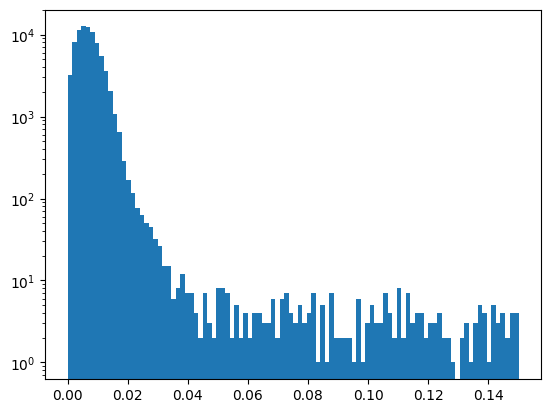

In [12]:
plt.hist(np.abs(yf[(f[:,0]>0)&(f[:,0]>0)]),bins=100)
plt.yscale('log')

In [13]:
pdf=bounds.E_pdf((mask.astype(int)*yf),2*np.pi*((f).T))

In [14]:
MM=50000
zv, tv, wv, sv = pdf.gen_ztw_c(MM)
wh, wn = bounds.nn_wnorm(wv)
print(wh.shape)

(2, 50000)


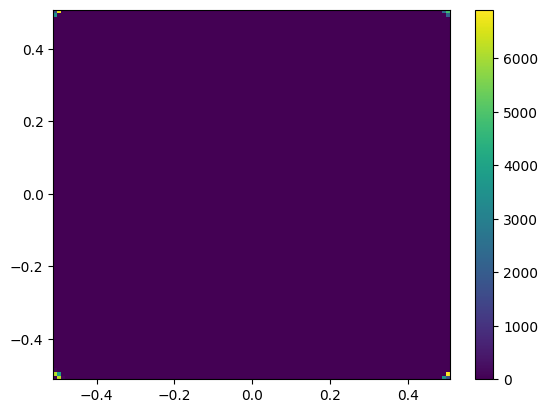

In [15]:
h2d,x2d,y2d,i2d=plt.hist2d(wh.T[:,0],wh.T[:,1],bins=100)
plt.colorbar()

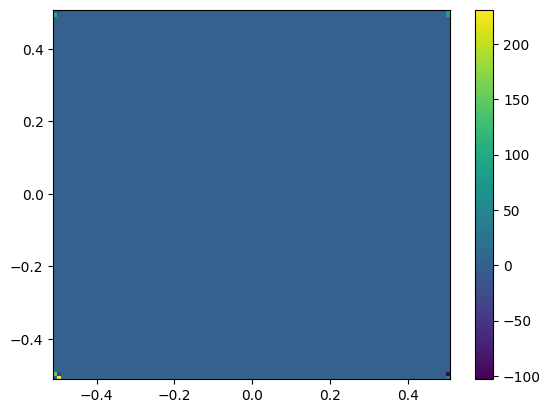

In [16]:
h2d,x2d,y2d,i2d=plt.hist2d(wh.T[:,0],wh.T[:,1],bins=100,weights=sv)
plt.colorbar()

(array([24727.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 25273.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

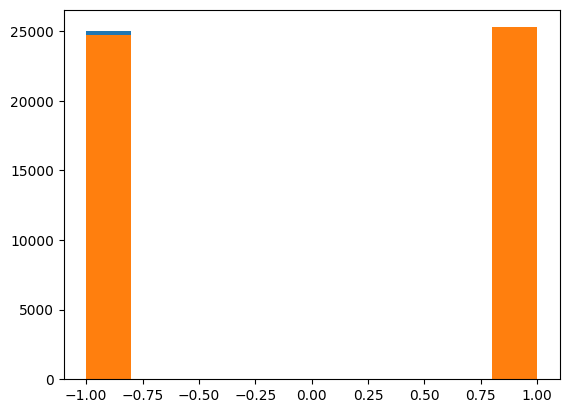

In [17]:
plt.hist(zv)
plt.hist(sv)

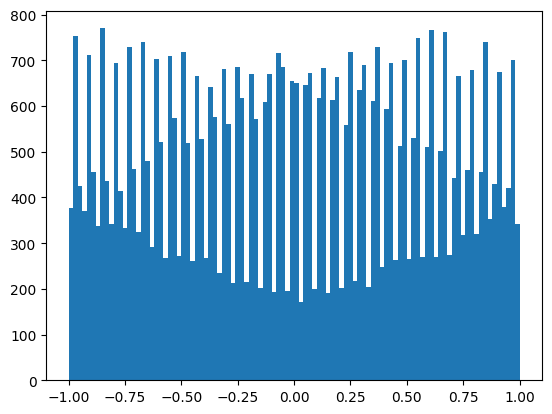

In [18]:
plt.hist(tv*zv,bins=100)
plt.show()

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
tensor_x = torch.Tensor(x).to(device) # transform to torch tensor
tensor_y = torch.Tensor(y.reshape(-1,1)).to(device)

In [21]:
print(torch.backends.cudnn.is_available())

False


In [22]:

class ShallowRegressor(nn.Module):
    def __init__(self):
        super(ShallowRegressor,self).__init__()
        self.fc1 = nn.Linear(2,MM)
        self.fc2 = nn.Linear(MM,1)
        self.fc1.bias.data.fill_(0.)
        self.fc2.bias.data.fill_(0.)
        self.fc1.weight.data.fill_(0.)
        self.fc2.weight.data.fill_(0.)        
        self.fc1.weight.data += torch.nn.Parameter(torch.Tensor(wh.T))
        self.fc1.bias.data += torch.nn.Parameter(torch.Tensor(tv*zv))      
        self.fc2.bias.data += torch.nn.Parameter(torch.Tensor(np.array([np.mean(y)])))
        self.fc2.weight.data += torch.nn.Parameter(torch.Tensor((1/2000)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def forward_info(self,x):
        x = F.relu(self.fc1(x))
        print(x)
        x = self.fc2(x)
        return x

In [23]:
model = ShallowRegressor()

In [24]:
for p in model.parameters():
    print(p)
model.fc1.weight.requires_grad = False
model.fc1.bias.requires_grad = False
for p in model.parameters():
    print(p)

Parameter containing:
tensor([[-0.4980, -0.5020],
        [-0.5030, -0.4970],
        [-0.4983,  0.5017],
        ...,
        [ 0.4997,  0.5003],
        [-0.5037, -0.4963],
        [-0.5006, -0.4994]], requires_grad=True)
Parameter containing:
tensor([-0.6756, -0.1907,  0.1884,  ..., -0.5567,  0.6106, -0.6697],
       requires_grad=True)
Parameter containing:
tensor([[-1.0000e-08,  1.0000e-08, -1.0000e-08,  ...,  1.0000e-08,
          1.0000e-08, -1.0000e-08]], requires_grad=True)
Parameter containing:
tensor([0.0034], requires_grad=True)
Parameter containing:
tensor([[-0.4980, -0.5020],
        [-0.5030, -0.4970],
        [-0.4983,  0.5017],
        ...,
        [ 0.4997,  0.5003],
        [-0.5037, -0.4963],
        [-0.5006, -0.4994]])
Parameter containing:
tensor([-0.6756, -0.1907,  0.1884,  ..., -0.5567,  0.6106, -0.6697])
Parameter containing:
tensor([[-1.0000e-08,  1.0000e-08, -1.0000e-08,  ...,  1.0000e-08,
          1.0000e-08, -1.0000e-08]], requires_grad=True)
Parameter co

In [25]:
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00001, momentum=0.9)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=0.00001)

In [26]:
loss_fn = torch.nn.MSELoss()

In [27]:
model = model.to(device)

In [28]:
print(tensor_x.shape)
ABS = 60
XX = np.linspace(-1,1,ABS,endpoint=False)
XXg = mt.grid_to_stack(np.meshgrid(XX,XX))
print(XXg.shape)

torch.Size([1600, 2])
(3600, 2)


In [29]:
model.eval()
YYg = model(torch.Tensor(XXg).to(device))

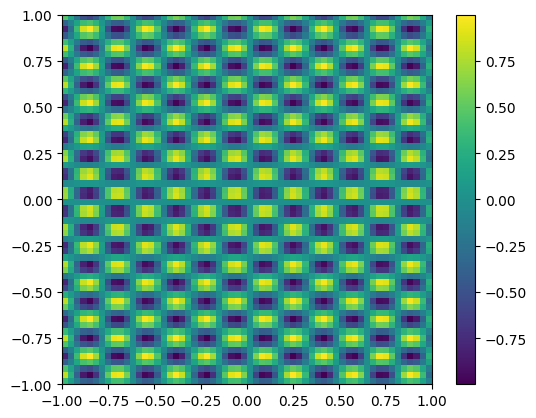

In [30]:
plt.imshow((np.sin(2.1*scale*np.pi*XXg[:,0])*np.sin(3.4*scale*np.pi*XXg[:,1])).reshape(ABS,ABS),extent=[-1, 1, -1, 1])
plt.colorbar()

torch.Size([3600, 1])


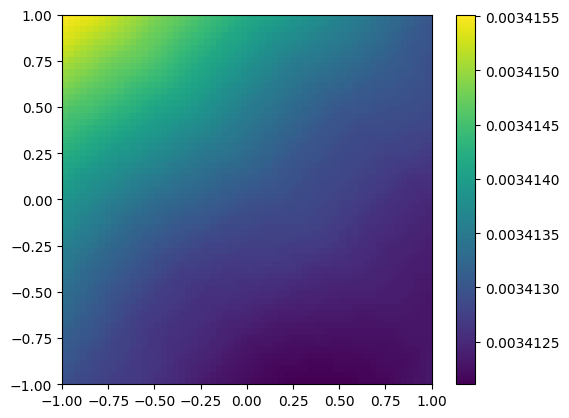

In [31]:
print(YYg.shape)
plt.imshow(YYg.detach().cpu().numpy().reshape(ABS,ABS),extent=[-1,1, -1, 1])
plt.colorbar()

torch.Size([3600, 1])
3.4058467e-06
1.998574704120086
2005.2468257382047


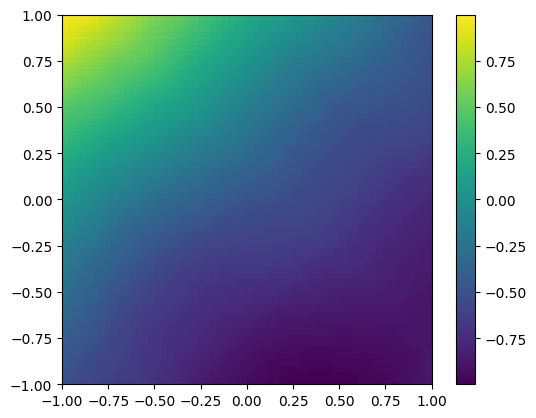

In [32]:
print(YYg.shape)
maxYY=np.max(YYg.detach().cpu().numpy())
maxXX=np.max((np.sin(2.1*1*np.pi*XXg[:,0])*np.sin(3.4*1*np.pi*XXg[:,1])))
factorYY=np.max(YYg.detach().cpu().numpy())-np.min(YYg.detach().cpu().numpy())
factorXX=np.max((np.sin(2.1*1*np.pi*XXg[:,0])*np.sin(3.4*1*np.pi*XXg[:,1])))-np.min((np.sin(2.1*1*np.pi*XXg[:,0])*np.sin(3.4*1*np.pi*XXg[:,1])))
print(factorYY)
print(factorXX)
print(maxYY/factorYY*factorXX+maxXX)
plt.imshow(YYg.detach().cpu().numpy().reshape(ABS,ABS)/factorYY*factorXX-maxYY/factorYY*factorXX+maxXX,extent=[-1,1, -1, 1])
plt.colorbar()

In [33]:
print(model.fc2.weight)
print(model.fc2.bias)
print(factorYY,factorXX,maxYY,maxXX)

Parameter containing:
tensor([[-1.0000e-08,  1.0000e-08, -1.0000e-08,  ...,  1.0000e-08,
          1.0000e-08, -1.0000e-08]], requires_grad=True)
Parameter containing:
tensor([0.0034], requires_grad=True)
3.4058467e-06 1.998574704120086 0.003415514 0.999287352060043


In [34]:
model.fc2.weight.data = model.fc2.weight.data/factorYY*factorXX
model.fc2.bias.data = model.fc2.bias.data-1

In [35]:
print(model.fc2.weight)
print(model.fc2.bias)

Parameter containing:
tensor([[-0.0059,  0.0059, -0.0059,  ...,  0.0059,  0.0059, -0.0059]],
       requires_grad=True)
Parameter containing:
tensor([-0.9966], requires_grad=True)


In [36]:
model.fc2.bias.data = model.fc2.bias.data-np.mean(model(torch.Tensor(XXg[:,:]).to(device)).detach().cpu().numpy())

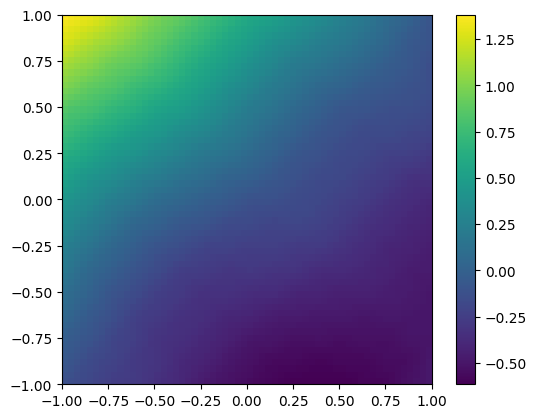

In [37]:
plt.imshow(model(torch.Tensor(XXg).to(device)).detach().cpu().numpy().reshape(ABS,ABS),extent=[-1,1, -1, 1])
plt.colorbar()

In [38]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [39]:
print(torch.Tensor(x[1:6,:]))
print(model(torch.Tensor(x[1:6,:]).to(device)))
print(model.forward_info((torch.Tensor(x[1:6,:]).to(device))))
print(model(torch.Tensor([[-.25,-.25],[.25,-.25],[-.25,.25],[.25,.25]]).to(device)))
print(model(torch.Tensor(XXg).to(device)).detach().cpu().numpy().reshape(ABS,ABS))

tensor([[-0.3395,  0.3874],
        [ 0.7412, -0.4921],
        [-0.8718,  0.9526],
        [-0.8880,  0.1164],
        [-0.7507,  0.5294]])
tensor([[-0.2607],
        [-0.1325],
        [-0.1822],
        [ 0.2498],
        [-0.1026]], grad_fn=<AddmmBackward0>)
tensor([[0.0000, 0.0000, 0.5519,  ..., 0.0000, 0.5894, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.4815, 0.0000],
        [0.0000, 0.0000, 1.1007,  ..., 0.0000, 0.5768, 0.0000],
        [0.0000, 0.1981, 0.6892,  ..., 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.8280,  ..., 0.0000, 0.7259, 0.0000]])
tensor([[-0.2607],
        [-0.1325],
        [-0.1822],
        [ 0.2498],
        [-0.1026]], grad_fn=<AddmmBackward0>)
tensor([[ 0.1727],
        [-0.0849],
        [-0.2129],
        [-0.2719]], grad_fn=<AddmmBackward0>)
[[ 1.3822559   1.3556384   1.3376993  ... -0.02071154 -0.05421555
  -0.0861541 ]
 [ 1.3429424   1.3214833   1.3068074  ... -0.03217828 -0.06259573
  -0.09272707]
 [ 1.3127552   1.2941219   1.

In [40]:
print(XXg[[2,5,200],:])
print(model(torch.Tensor(XXg[[2,5,200,566,632],:]).to(device)))

[[-0.93333333 -1.        ]
 [-0.83333333 -1.        ]
 [-0.33333333 -0.9       ]]
tensor([[1.3377],
        [1.2872],
        [0.7742],
        [0.4646],
        [0.2811]], grad_fn=<AddmmBackward0>)


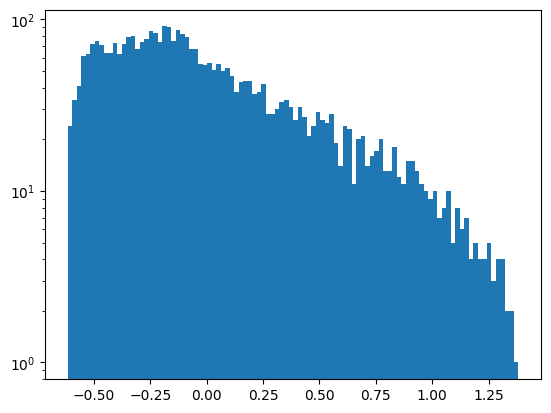

In [41]:
plt.hist(model(torch.Tensor(XXg[:,:]).to(device)).detach().cpu().numpy(),bins=100)
plt.yscale('log')

plt.hist(model.fc1.weight.data.detach().cpu().numpy(),bins=100)

In [42]:
outputs = model(torch.Tensor(xv).to(device))
print(outputs.T)
print(loss_fn(outputs, torch.Tensor(yv.reshape(-1,1)).to(device)))
outputs = model(torch.Tensor(x).to(device))
print(outputs.T)
print(loss_fn(outputs, torch.Tensor(y.reshape(-1,1)).to(device)))

tensor([[-0.6142, -0.0580, -0.3586,  ..., -0.2544,  1.2746,  0.5732]],
       grad_fn=<PermuteBackward0>)
tensor(0.4126, grad_fn=<MseLossBackward0>)
tensor([[-0.5543, -0.2607, -0.1325,  ...,  0.1279, -0.1618,  0.2227]],
       grad_fn=<PermuteBackward0>)
tensor(0.3958, grad_fn=<MseLossBackward0>)


In [43]:
print(model.fc1.weight)
print(model.fc2.weight)
print(model.fc1.bias)
print(model.fc2.bias)

Parameter containing:
tensor([[-0.4980, -0.5020],
        [-0.5030, -0.4970],
        [-0.4983,  0.5017],
        ...,
        [ 0.4997,  0.5003],
        [-0.5037, -0.4963],
        [-0.5006, -0.4994]])
Parameter containing:
tensor([[-0.0059,  0.0059, -0.0059,  ...,  0.0059,  0.0059, -0.0059]],
       requires_grad=True)
Parameter containing:
tensor([-0.6756, -0.1907,  0.1884,  ..., -0.5567,  0.6106, -0.6697])
Parameter containing:
tensor([-1.1615], requires_grad=True)


In [44]:
early_stopper = EarlyStopper(patience=11, min_delta=0)
loss_history = []
vloss_history = []
tmeanloss_history = []
tmaxloss_history = []
tminloss_history = []
for epoch in range(50000):  # loop over the dataset multiple times


    # zero the parameter gradients
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = model(tensor_x)
    loss = loss_fn(outputs, tensor_y)
    loss_history.append(loss)
    loss.backward()
    optimizer.step()
    # print statistics
    with torch.no_grad(): 
        outputs = model(torch.Tensor(xv).to(device))
        vloss = loss_fn(outputs, torch.Tensor(yv.reshape(-1,1)).to(device))  
        vloss_history.append(vloss)
    with torch.no_grad(): 
        outputs = model(torch.Tensor(xt).to(device))
        tloss = loss_fn(outputs, torch.Tensor(yt.reshape(-1,1)).to(device)) 
        outputs = model(torch.Tensor(xtt).to(device))
        ttloss = loss_fn(outputs, torch.Tensor(ytt.reshape(-1,1)).to(device)) 
        outputs = model(torch.Tensor(xttt).to(device))
        tttloss = loss_fn(outputs, torch.Tensor(yttt.reshape(-1,1)).to(device)) 
        outputs = model(torch.Tensor(xtttt).to(device))
        ttttloss = loss_fn(outputs, torch.Tensor(ytttt.reshape(-1,1)).to(device)) 
        outputs = model(torch.Tensor(xttttt).to(device))
        tttttloss = loss_fn(outputs, torch.Tensor(yttttt.reshape(-1,1)).to(device))         
        tlosses = np.array([tloss.detach().cpu().numpy(),ttloss.detach().cpu().numpy(),tttloss.detach().cpu().numpy(),ttttloss.detach().cpu().numpy(),tttttloss.detach().cpu().numpy()])

        tmeanloss_history.append(np.mean(tlosses))
        tmaxloss_history.append(np.max(tlosses))
        tminloss_history.append(np.min(tlosses))
      

    if epoch%50==0:
        print(f'[{epoch + 1}] loss: {loss.item():.3f} vloss: {vloss.item():.3f}')
    if early_stopper.early_stop(vloss) and epoch>30000:             
        break
print('Finished Training')

[1] loss: 0.396 vloss: 0.368
[51] loss: 0.235 vloss: 0.234
[101] loss: 0.234 vloss: 0.234
[151] loss: 0.234 vloss: 0.234
[201] loss: 0.233 vloss: 0.234
[251] loss: 0.233 vloss: 0.234
[301] loss: 0.233 vloss: 0.234
[351] loss: 0.233 vloss: 0.234
[401] loss: 0.232 vloss: 0.235
[451] loss: 0.232 vloss: 0.235
[501] loss: 0.232 vloss: 0.235
[551] loss: 0.232 vloss: 0.235
[601] loss: 0.232 vloss: 0.235
[651] loss: 0.231 vloss: 0.235
[701] loss: 0.231 vloss: 0.235
[751] loss: 0.231 vloss: 0.235
[801] loss: 0.231 vloss: 0.235
[851] loss: 0.231 vloss: 0.235
[901] loss: 0.231 vloss: 0.235
[951] loss: 0.231 vloss: 0.235
[1001] loss: 0.231 vloss: 0.235
[1051] loss: 0.231 vloss: 0.236
[1101] loss: 0.230 vloss: 0.236
[1151] loss: 0.230 vloss: 0.236
[1201] loss: 0.230 vloss: 0.236
[1251] loss: 0.230 vloss: 0.236
[1301] loss: 0.230 vloss: 0.236
[1351] loss: 0.230 vloss: 0.236
[1401] loss: 0.230 vloss: 0.236
[1451] loss: 0.230 vloss: 0.236
[1501] loss: 0.230 vloss: 0.236
[1551] loss: 0.230 vloss: 0.236

KeyboardInterrupt: 

In [ ]:
print(model.fc1.weight)
print(model.fc2.weight)
print(model.fc1.bias)
print(model.fc2.bias)

In [ ]:
outputs = model(torch.Tensor(xv).to(device))
print(outputs.T)
print(loss_fn(outputs, torch.Tensor(yv.reshape(-1,1)).to(device)))
outputs = model(torch.Tensor(x).to(device))
print(outputs.T)
print(loss_fn(outputs, torch.Tensor(y.reshape(-1,1)).to(device)))

In [ ]:
plt.imshow(model(torch.Tensor(XXg).to(device)).detach().cpu().numpy().reshape(ABS,ABS),extent=[-1,1, -1, 1])
plt.colorbar()

In [ ]:
plt.plot(tmeanloss_history)
plt.plot(tminloss_history)
plt.plot(tmaxloss_history)
plt.plot([l.detach().cpu().numpy() for l in loss_history])
plt.plot([l.detach().cpu().numpy() for l in vloss_history])
plt.title("Loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend(["Mean Test Loss", "Min Test Loss", "Max Test Loss","Val Loss","Train Loss"])

In [ ]:
print(" L Freq ",freqL)
print(" S Freq ",freqS)
print(" N ",N*mult/2)
print(" M ",MM)
print(" Number of Epochs ",len(tmeanloss_history))
print(" Test Mean Loss: ",tmeanloss_history[-1])
print(" Test Min Loss: ",tminloss_history[-1])
print(" Test Max Loss: ",tmaxloss_history[-1])
print(" Val Loss: ",vloss_history[-1].detach().cpu().numpy())
print(" Train Loss: ",loss_history[-1].detach().cpu().numpy())
print(" Generalization Variance: ",tmaxloss_history[-1]-tminloss_history[-1])
print(" Generalization Bound: ",tmaxloss_history[-1]-loss_history[-1].detach().cpu().numpy())

plt.hist(model.fc1.weight.data.detach().cpu().numpy(),bins=100)

plt.hist(model.fc2.weight.data.detach().cpu().numpy(),bins=100)

plt.hist(model.fc2.bias.data.detach().cpu().numpy(),bins=100)